# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Data Loading

In [2]:
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.shape

(1067371, 8)

In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

# Data Inspection

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [6]:
df["Description"].isna().sum()

np.int64(4382)

In [7]:
df["Customer ID"].isna().sum()

np.int64(243007)

# Data Cleaning

In [8]:
df = df.dropna(subset=["Customer ID","Description"])
df.shape

(824364, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(df['InvoiceDate'].dtype)

datetime64[ns]


In [11]:
print(df.duplicated().sum())

26479


In [12]:
df.duplicated().sum()

np.int64(26479)

In [13]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# Feature Engineering

In [14]:
df["Revenue"] = df.Quantity * df.Price
df = df.rename(columns={"Customer ID":"CustID"})
df["CustID"] = df["CustID"].astype(int)

In [15]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [16]:
df = df[df['Quantity'] > 0]
df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(df.shape)

(779495, 9)


In [17]:
print(df[df['Price'] <= 0].shape)

(70, 9)


In [18]:
df = df[df['Price'] > 0]
df.shape

(779425, 9)

# Exploratory Data Analysis

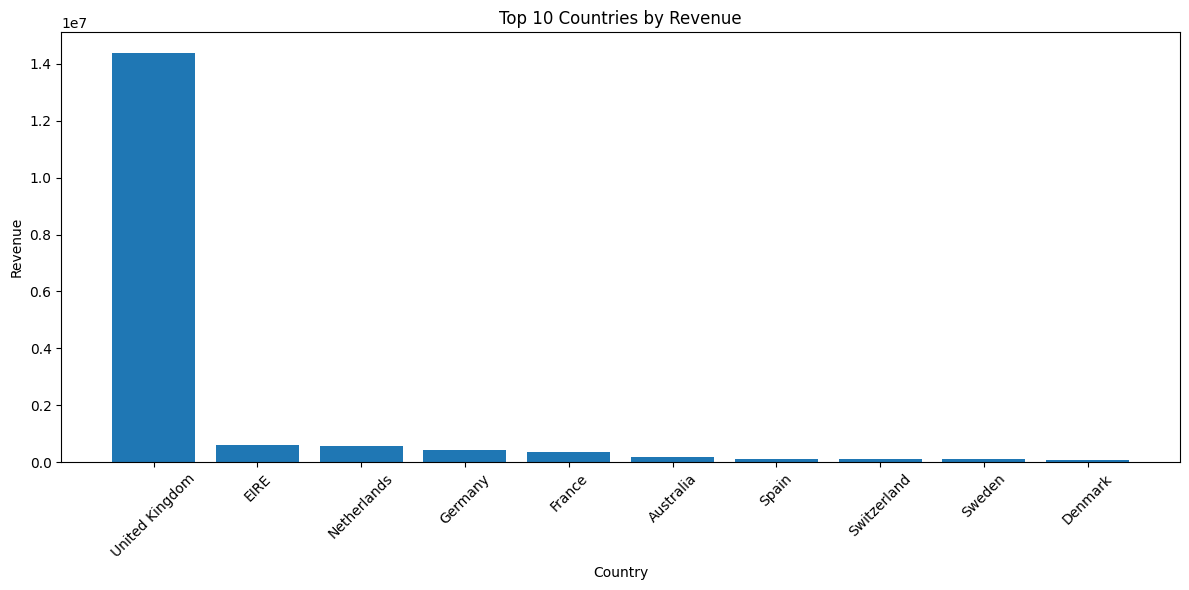

In [19]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_countries.index, top_countries.values)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

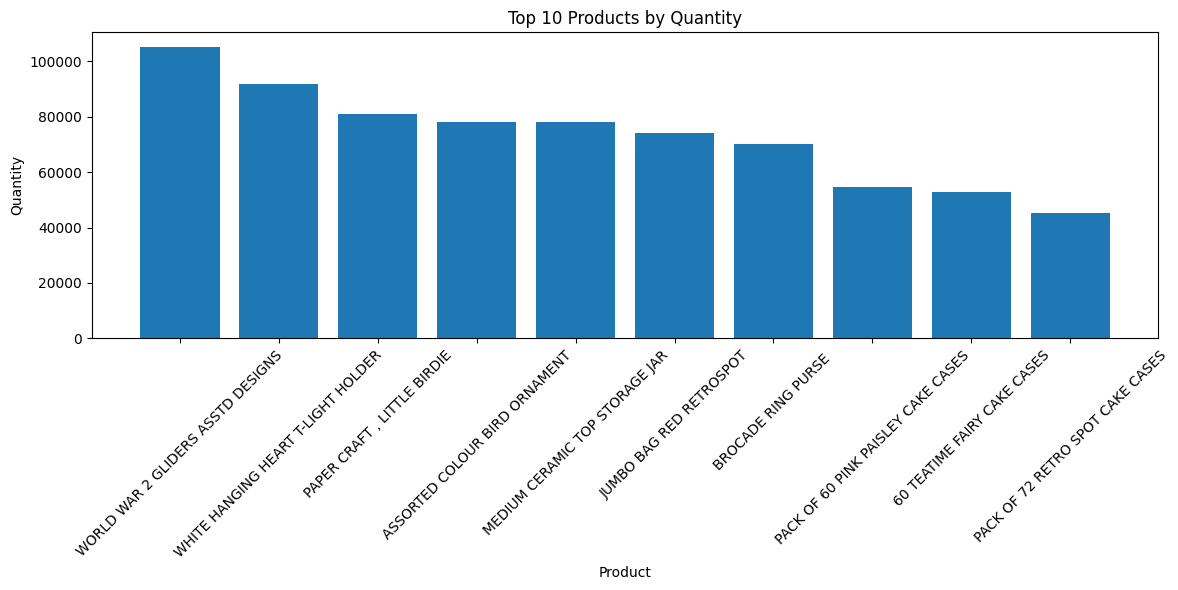

In [20]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top_products.index, top_products.values)
plt.title("Top 10 Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

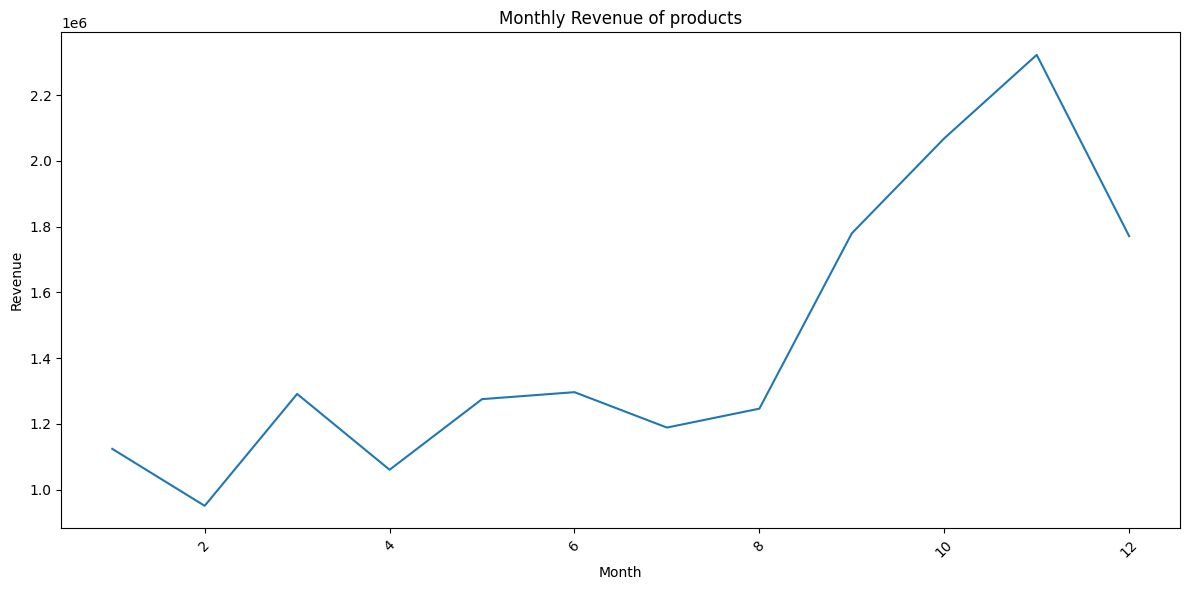

In [22]:
monthly_revenue = df.groupby("Month")["Revenue"].sum()
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Monthly Revenue of products")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

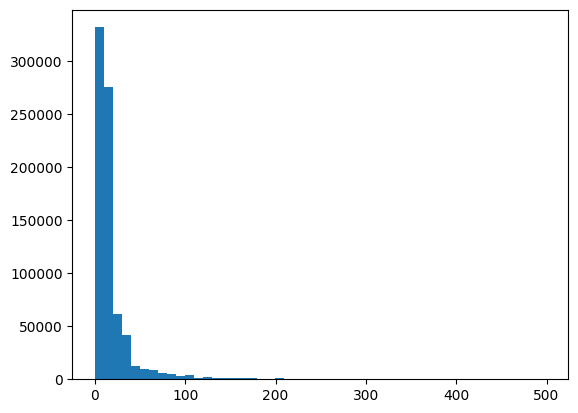

In [23]:
plt.hist(df[df['Revenue'] < 500]['Revenue'], bins=50)
plt.show()

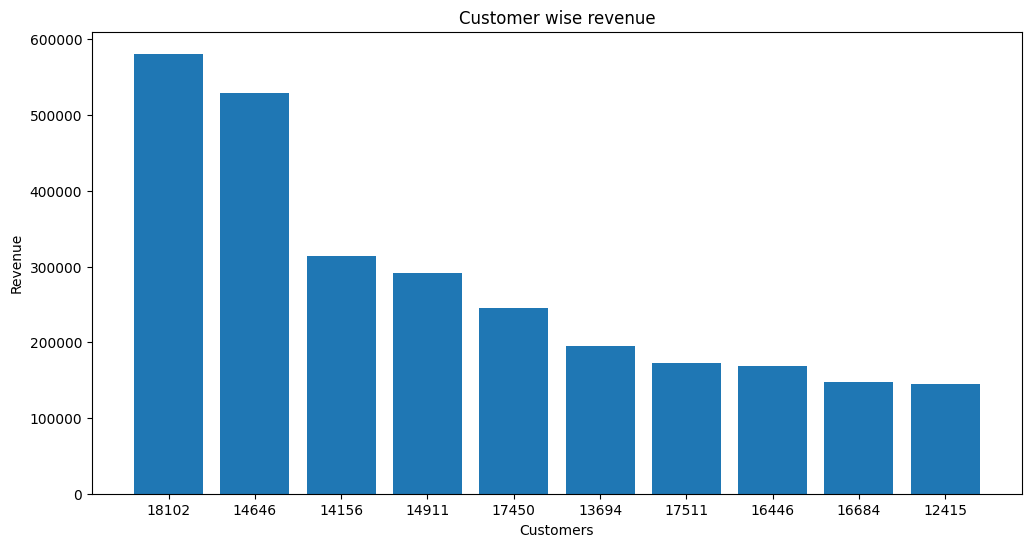

In [24]:
top_cust_by_rev = df.groupby("CustID")["Revenue"].sum().sort_values(ascending=False).head(10)
top_cust_by_rev.index = top_cust_by_rev.index.astype(str)
plt.figure(figsize=(12,6))
plt.bar(top_cust_by_rev.index, top_cust_by_rev.values)
plt.title("Customer wise revenue")
plt.xlabel("Customers")
plt.ylabel("Revenue")
plt.show()

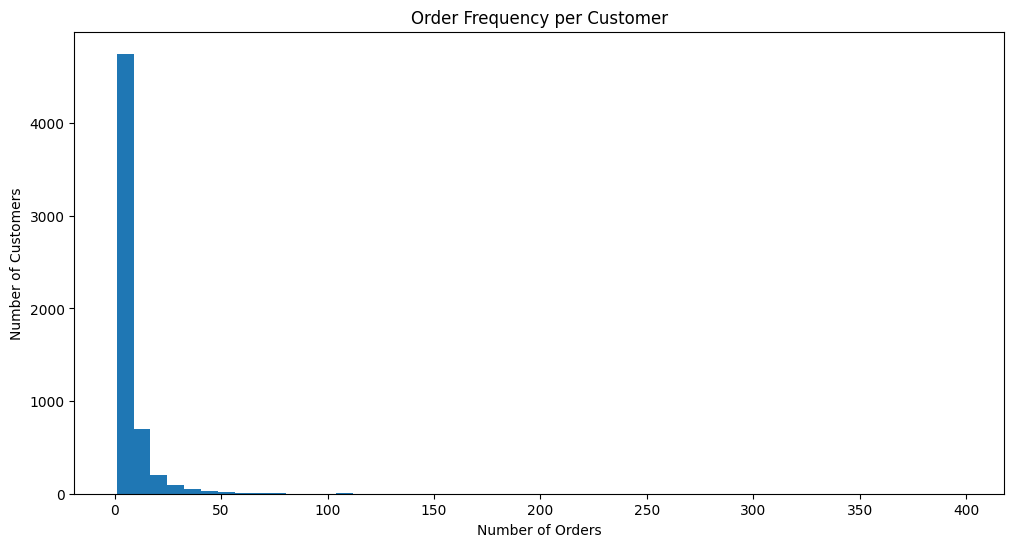

In [25]:
order_freq = df.groupby("CustID")["Invoice"].nunique()
plt.figure(figsize=(12,6))
plt.hist(order_freq, bins=50)
plt.title("Order Frequency per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()

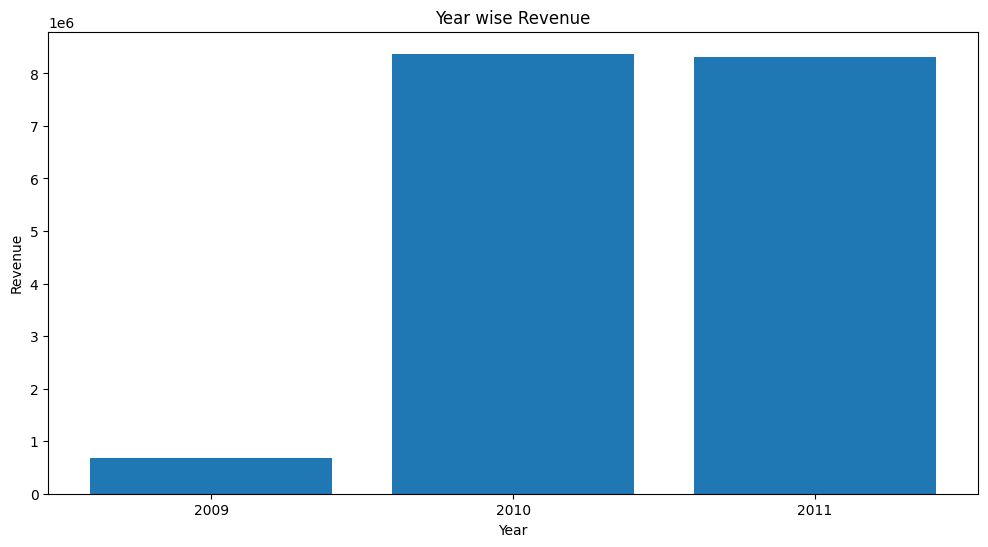

In [26]:
yr_wise_rev = df.groupby("Year")["Revenue"].sum().sort_index()
years = yr_wise_rev.index.astype(str)
plt.figure(figsize=(12,6))
plt.bar(years, yr_wise_rev.values)
plt.title("Year wise Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.show()

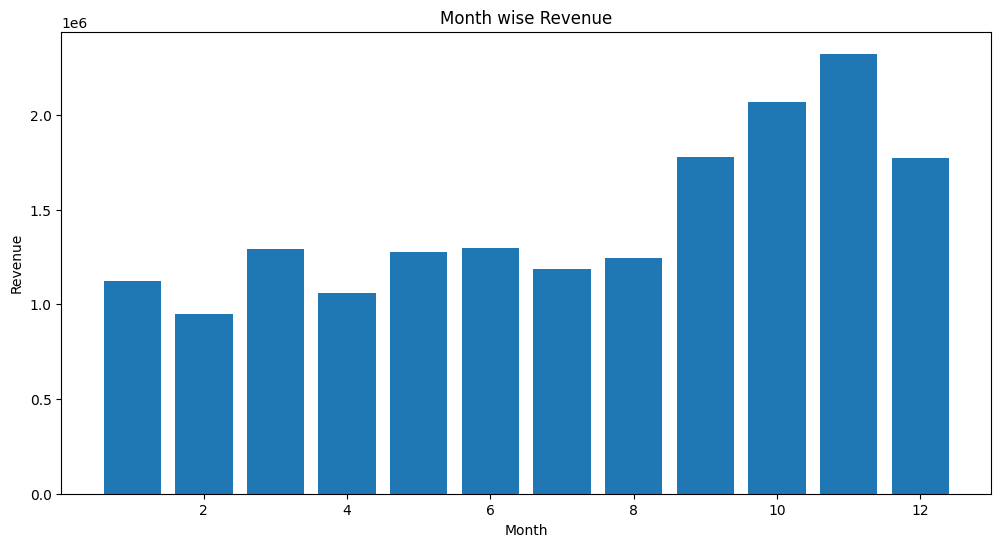

In [27]:
mo_wise_rev = df.groupby("Month")["Revenue"].sum().sort_index()
plt.figure(figsize=(12,6))
plt.bar(mo_wise_rev.index, mo_wise_rev.values)
plt.title("Month wise Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

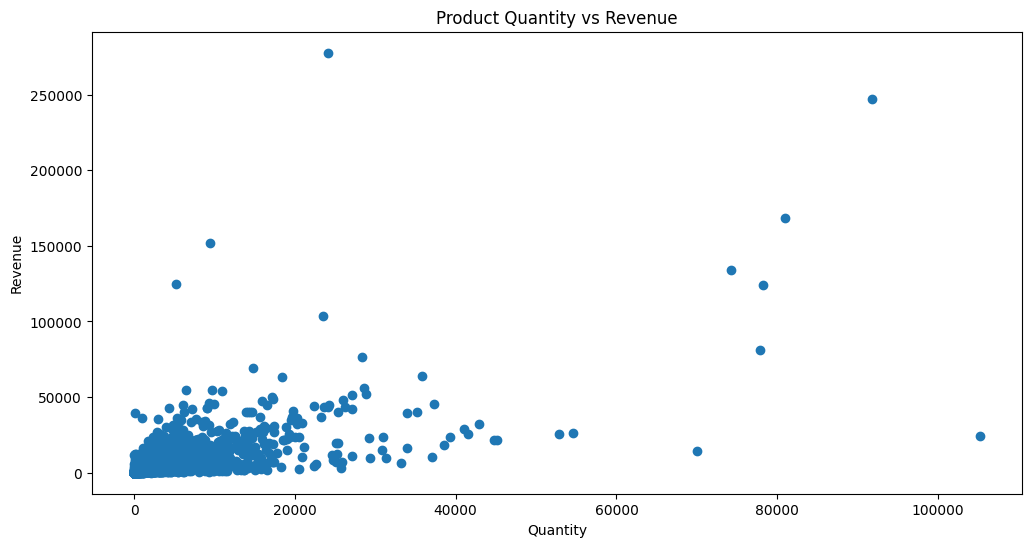

In [28]:
quan_vs_rev = df.groupby("Description")[["Quantity","Revenue"]].sum()
plt.figure(figsize=(12,6))
plt.scatter(quan_vs_rev["Quantity"], quan_vs_rev["Revenue"])
plt.title("Product Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.show()

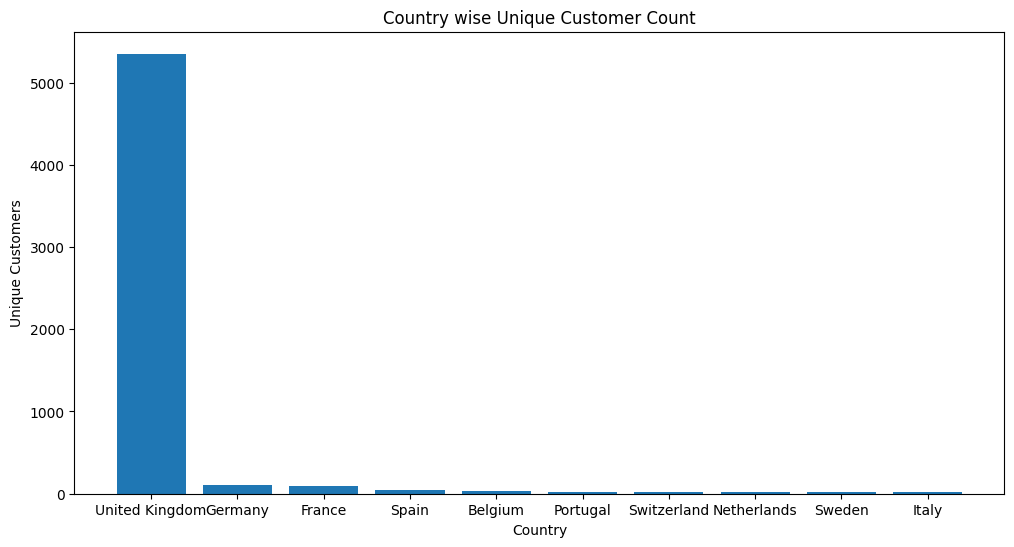

In [29]:
con_wise_cust_count = df.groupby("Country")["CustID"].nunique().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(con_wise_cust_count.index, con_wise_cust_count.values)
plt.title("Country wise Unique Customer Count")
plt.xlabel("Country")
plt.ylabel("Unique Customers")
plt.show()

# Train / Test Split & RFM Analysis

In [30]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
split_date = df['InvoiceDate'].max() - pd.DateOffset(months=6)

past = df[df['InvoiceDate'] <= split_date]
future = df[df['InvoiceDate'] > split_date]

print('Past shape:', past.shape, '| Future shape:', future.shape)

reference_date = past['InvoiceDate'].max() + pd.Timedelta(days=1)

Past shape: (538840, 11) | Future shape: (240585, 11)


In [31]:
rfm = past.groupby('CustID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.head()

,CustID,Recency,Frequency,Monetary
0,12346,143,12,77556.46
1,12347,64,4,2434.96
2,12348,66,4,1709.40
3,12349,225,3,2671.14
4,12350,127,1,334.40


# Customer Segmentation

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error,mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score

In [33]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

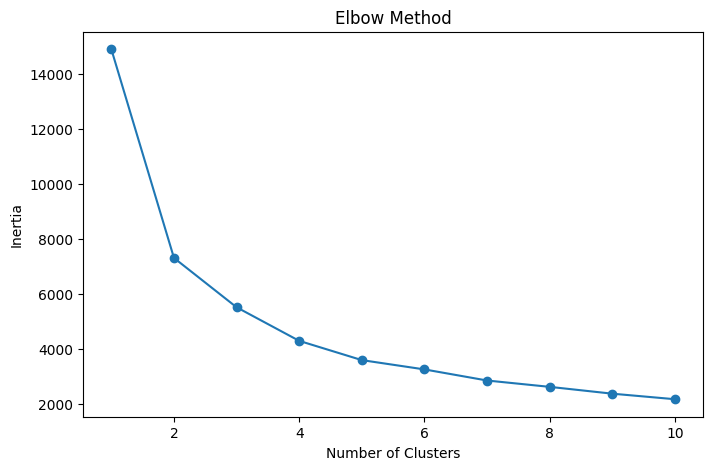

In [34]:
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [35]:
km = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = km.fit_predict(rfm_scaled)
print(rfm['Cluster'].value_counts())

Cluster
3    1981
1    1500
0     795
2     691
Name: count, dtype: int64


In [36]:
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean())

            Recency  Frequency      Monetary
Cluster                                     
0         32.966038  18.227673  10148.283089
1        180.045333   4.502000   1723.175751
2         20.982634   3.473227   1033.805601
3        274.379101   1.330641    313.067124


In [37]:
cluster_labels = {0: 'Lost', 1: 'At Risk', 2: 'Champions', 3: 'VIP'}
rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
print(rfm['Segment'].value_counts())

Segment
VIP          1981
At Risk      1500
Lost          795
Champions     691
Name: count, dtype: int64


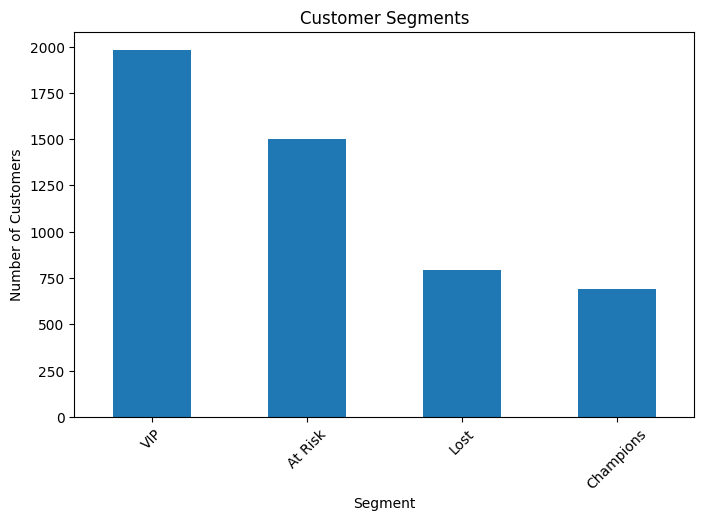

In [38]:
rfm['Segment'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()

In [39]:
future_revenue = future.groupby('CustID')['Revenue'].sum().reset_index()
future_revenue.columns = ['CustID', 'Future_Revenue']
print(future_revenue.head())

   CustID  Future_Revenue
0   12347         2486.57
1   12348          310.00
2   12349         1757.55
3   12352          944.23
4   12356           58.35


In [40]:
rfm_model = rfm.merge(future_revenue, on='CustID', how='inner')
print(rfm_model.shape)
print(rfm_model.head())

(2577, 7)
   CustID  Recency  Frequency  Monetary  Cluster  Segment  Future_Revenue
0   12347       64          4   2434.96        1  At Risk         2486.57
1   12348       66          4   1709.40        1  At Risk          310.00
2   12349      225          3   2671.14        1  At Risk         1757.55
3   12352       79          7   1905.61        1  At Risk          944.23
4   12356       63          5   6313.38        1  At Risk           58.35


In [41]:
X = rfm_model[['Recency', 'Frequency', 'Monetary', 'Cluster']]
y = rfm_model['Future_Revenue']

print(X.shape)

(2577, 4)


# Model Training & Evaluation

In [42]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
lr = LinearRegression()
lr.fit(train_X, train_y)
predict_lr = lr.predict(test_X)
print("Linear Regression RMSE:", root_mean_squared_error(test_y, predict_lr))
print("Linear Regression R2:", r2_score(test_y, predict_lr))
print("Linear Regression MSE:", mean_squared_error(test_y, predict_lr))

Linear Regression RMSE: 4539.407052125595
Linear Regression R2: 0.8110363238165601
Linear Regression MSE: 20606216.38488759


In [44]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1, n_estimators=50)
rf.fit(train_X, train_y)
predict_rf = rf.predict(test_X)
print("Random Forest RMSE:", root_mean_squared_error(test_y, predict_rf))
print("Random Forest R2:", r2_score(test_y, predict_rf))    
print("Random Forest MSE:", mean_squared_error(test_y, predict_rf))

Random Forest RMSE: 5709.1830633812815
Random Forest R2: 0.7010985575934208
Random Forest MSE: 32594771.25119967


In [45]:
xgb = XGBRegressor(random_state=42, n_jobs=-1)
xgb.fit(train_X, train_y)
predict_xgb = xgb.predict(test_X)
print("XGBoost RMSE:", root_mean_squared_error(test_y, predict_xgb))
print("XGBoost R2:", r2_score(test_y, predict_xgb))
print("XGBoost MSE:", mean_squared_error(test_y, predict_xgb))

XGBoost RMSE: 7511.109448641946
XGBoost R2: 0.48264547251664947
XGBoost MSE: 56416765.149478324


# Hyperparameter Tuning

In [46]:
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_rs = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                            rf_params, n_iter=20, cv=3, scoring='r2', random_state=42, n_jobs=-1)

rf_rs.fit(train_X, train_y)
print("Best params:", rf_rs.best_params_)

Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5}


In [47]:
rf_hyp= RandomForestRegressor(n_estimators=100, min_samples_split=5, min_samples_leaf=1, max_features='log2', max_depth=20, random_state=42, n_jobs=-1)
rf_hyp.fit(train_X, train_y)
predict_rf_hyp = rf_hyp.predict(test_X)
print("Random Forest RMSE:", root_mean_squared_error(test_y, predict_rf_hyp))
print("Random Forest R2:", r2_score(test_y, predict_rf_hyp))
print("Random Forest MSE:", mean_squared_error(test_y, predict_rf_hyp))

Random Forest RMSE: 6090.750307605084
Random Forest R2: 0.6598099046781678
Random Forest MSE: 37097239.309591435


# Cross Validation

In [48]:
scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("CV Scores:", scores)
print("Mean R2:", scores.mean())
print("Std:", scores.std())

CV Scores: [0.6981001  0.69204478 0.71797491 0.09003865 0.77228179]
Mean R2: 0.5940880475760695
Std: 0.25360630389127464


In [49]:
scores_tuned = cross_val_score(rf_rs.best_estimator_, X, y, cv=5, scoring='r2')
print("Tuned CV Scores:", scores_tuned)
print("Tuned Mean R2:", scores_tuned.mean())
print("Tuned Std:", scores_tuned.std())

Tuned CV Scores: [0.55070684 0.60933703 0.39906205 0.11698038 0.56670727]
Tuned Mean R2: 0.44855871498118277
Tuned Std: 0.1803535974375957


# Feature Importance

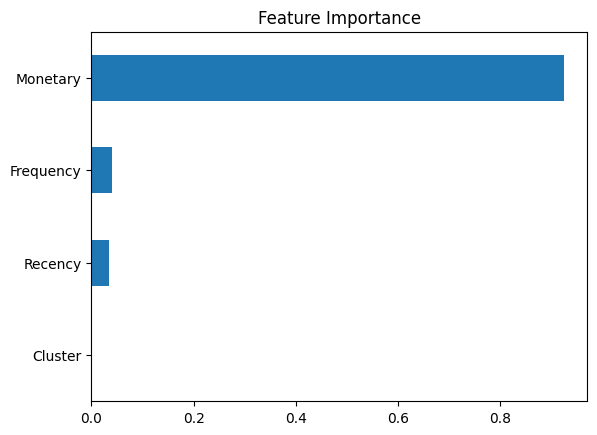

In [50]:
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
feat_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

# Save Model & Data

In [51]:
import joblib
joblib.dump(rf, 'clv_model.pkl')
print("Model saved!")

Model saved!


In [52]:
df.to_csv('processed_data.csv', index=False)
rfm_model.to_csv('rfm_model.csv', index=False)